In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append("../../")
import data_loading as dl
from importlib import reload
reload(dl)

from microfit import run_plotter as rp
from microfit import histogram as hist

from microfit import variable_definitions as vdef
from microfit import selections

from microfit import detsys
from microfit import xsec_covariances as xs
from microfit.xsec_signal_generator import XsecCovarHistGenerator

In [3]:
keep_vars = [
    "Signal_1e1p", "mc_signal_1e1p", "nu_pdg", "TrueElecIdx", "TrueLeadProtonIdx", "InFV", "HasNoMesons", "TrueNElec", "TrueNProt", 
    "TrueDeltaPT", "TrueDeltaAlphaT", "TruePN", "TrueAlpha3D",
    "TrueLeadProtonKE", "TrueLeadProtonModMom", "TrueLeadProtonE", "TrueLeadProtonMomX", "TrueLeadProtonMomY", "TrueLeadProtonMomZ",
    "TrueElecKE", "TrueElecModMom", "TrueElecE", "TrueElecMomX", "TrueElecMomY", "TrueElecMomZ",

    "Sel_1e1p", "sel_1e1p_w_cuts", "RecoElectronCandidateIdx", "RecoLeadProtonCandidateIdx", "InFV_reco",
    "RecoElecPassMomCut", "RecoLeadProtonPassMomCut", "n_reco_tracks", "n_reco_showers",
    "RecoDeltaPT", "RecoDeltaAlphaT", "RecoPN", "RecoAlpha3D", "RecoECal", "Reco_mag_q", "RecoPL",
    "RecoLeadProtonKE", "RecoLeadProtonModMom", "RecoLeadProtonMomX", "RecoLeadProtonMomY", "RecoLeadProtonMomZ",
    "RecoElecE", "RecoElecModMom", "RecoElecMomX", "RecoElecMomY", "RecoElecMomZ",

    "RecoLeadProton_trk_len", "RecoLeadProton_trk_trunk_dEdx_y", "RecoLeadProton_dEdx_y_per_trklen",
    "RecoLeadProtonCandidate_trk_pid", "RecoElectronCandidate_shr_pid", "RecoElectron_conversion_dist",

    "nproton", "npion", "npi0", "nelec", "nmuon", "isVtxInFiducial",

    "nslice", "selected", "shr_energy_tot_cali", "_opfilter_pe_beam", "_opfilter_pe_veto", "bnbdata", "extdata",
    "CosmicIPAll3D", "hits_ratio", "shrmoliereavg", "subcluster", "trkfit", "trkshrhitdist2", "tksh_distance",
    "shr_tkfit_nhits_tot", "shr_tkfit_dedx_max", "tksh_angle", "shr_trk_len", "reco_e",
    "trkpid", "trk_len", "n_showers_contained", "protonenergy_corr", "n_tracks_contained",
    "pi0_radlen1", "pi0_radlen2", "pi0_score", "nonpi0_score", "bkg_score",

    # "InFV_1muNp", "TrueMuonIdx_1muNp", "TrueLeadProtonIdx_1muNp", "TrueNProt_1muNp", "TrueFSPions_1muNp", "Signal_1mu1p", 
    # "TrueDeltaPT_1mu1p", "TrueDeltaAlphaT_1mu1p", "TruePN_1mu1p", "TrueAlpha3D_1mu1p",
    # "TrueLeadProtonE_1muNp", "TrueLeadProtonMomX_1muNp", "TrueLeadProtonMomY_1muNp", "TrueLeadProtonMomZ_1muNp",
    # "TrueMuonE_1muNp", "TrueMuonMomX_1muNp", "TrueMuonMomY_1muNp", "TrueMuonMomZ_1muNp",

    # "sel_CC1p0pi", "InFV_reco_1muNp", "MuonCandidateIdx_1muNp", "LeadProtonIdx_1muNp", "LeadProtonPassMomentumCut_1muNp", "PFPStartsInPCV_1muNp", "PassTopoScoreCut_1muNp",
    # "PassNuMuCCSelection_1muNp", "NoRecoShowers_1muNp", "MuonContained_1muNp", "PassMuonMomentumCut_1muNp", "PassMuonQualCut_1muNp",
    # "LeadProtonPassMomentumCut_1muNp", "NProtons_1muNp",
    # "RecoDeltaPT_1mu1p", "RecoDeltaAlphaT_1mu1p", "RecoPN_1mu1p", "RecoAlpha3D_1mu1p", "RecoECal_1mu1p", "RecoPL_1mu1p",
    # "RecoLeadProtonE_1muNp", "RecoLeadProtonMomentum_1muNp", "RecoLeadProtonMomX_1muNp", "RecoLeadProtonMomY_1muNp", "RecoLeadProtonMomZ_1muNp", 
    # "RecoMuonE_1muNp", "RecoMuonMomentum_1muNp", "RecoMuonMomX_1muNp", "RecoMuonMomY_1muNp", "RecoMuonMomZ_1muNp",
]

keep_vars_detsys = keep_vars + ["ccnc", "nu_pdg",]

In [10]:
RUN = ["3"]
blinded = True
data="bnb"

rundata, mc_weights, data_pot = dl.load_runs(
    RUN,
    data=data,
    loadpi0variables=False,
    loadshowervariables=True,
    loadrecoveryvars=False,
    loadsystematics=True,
    numupresel=False,
    loadnumuvariables=False,
    use_bdt=True,
    load_lee=False,
    #load_numu_tki=True,
    load_nue_tki=True,
    keep_columns=keep_vars,
    blinded=blinded,
    load_crt_vars=False,
    enable_cache=True,
)

Loading run 3
Updating keep_columns with truth-filtering variables: {'nu_pdg', 'ccnc'}


In [11]:
run_combo = "Run"
for run in RUN:
    run_combo += run

/exp/uboone/data/users/cthorpe/PELEE_2023_Samples/run3/detvar/nuepresel/overlay_pelee_ntuples_bnb_nu_detvar_run3_LYDown_reprocess_ana.root
Loading data from: /exp/uboone/data/users/cthorpe/PELEE_2023_Samples/run3/detvar/nuepresel/overlay_pelee_ntuples_bnb_nu_detvar_run3_LYDown_reprocess_ana.root


../../data_loading.py:876: RuntimeWarning: invalid value encountered in true_divide
  df["proton_pz"] = np.where((mc_E_prot > 0), mc_pz_prot / mc_p_prot, np.nan)


Calc true TKI variables for leading proton only
Calc true GKI variables for leading proton only
Calc reco TKI variables for leading proton only
Calc reco GKI variables for leading proton only
/exp/uboone/data/users/cthorpe/PELEE_2023_Samples/run3/detvar/nuepresel/prodgenie_bnb_intrinsic_nue_overlay_DetVar_LYDown_v08_00_00_37_run3b_reco2_reco2.root
Loading data from: /exp/uboone/data/users/cthorpe/PELEE_2023_Samples/run3/detvar/nuepresel/prodgenie_bnb_intrinsic_nue_overlay_DetVar_LYDown_v08_00_00_37_run3b_reco2_reco2.root
Calc true TKI variables for leading proton only
Calc true GKI variables for leading proton only
Calc reco TKI variables for leading proton only
Calc reco GKI variables for leading proton only
('RecoDeltaPT', None, None, '$\\delta p_T$ [GeV/c]', False, None, [0, 0.3, 1.7])



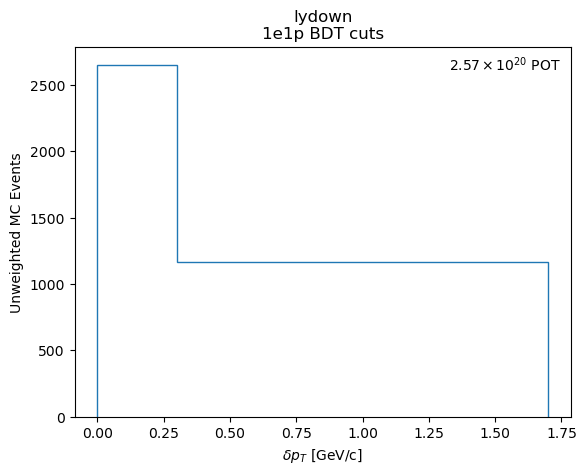

('RecoDeltaAlphaT', None, None, '$\\delta \\alpha_T$ [degrees]', False, None, [0, 80.0, 180.0])



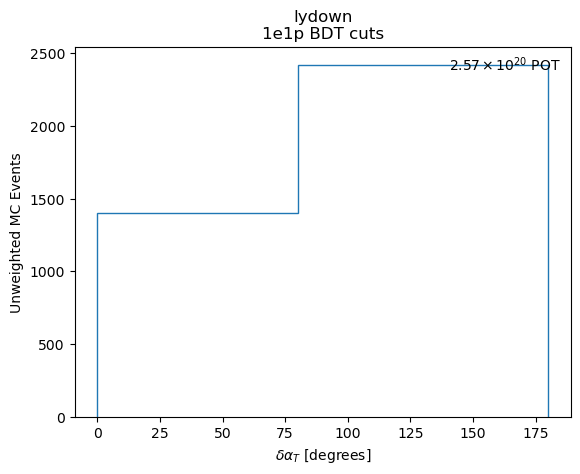

('RecoPN', None, None, '$p_n$ [GeV/c]', False, None, [0, 0.3, 1.7])



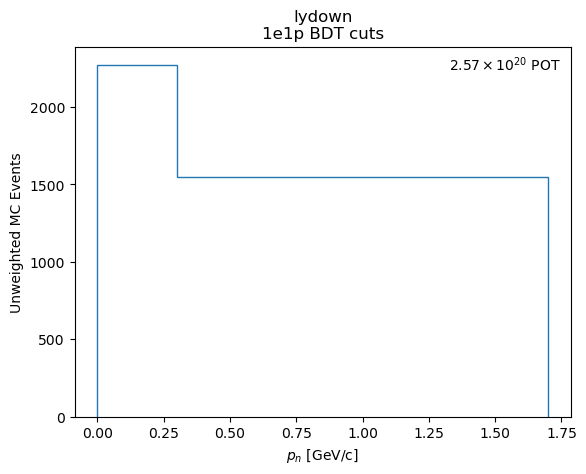

('RecoAlpha3D', None, None, '$\\alpha_{3D}$ [degrees]', False, None, [0, 90.0, 180.0])



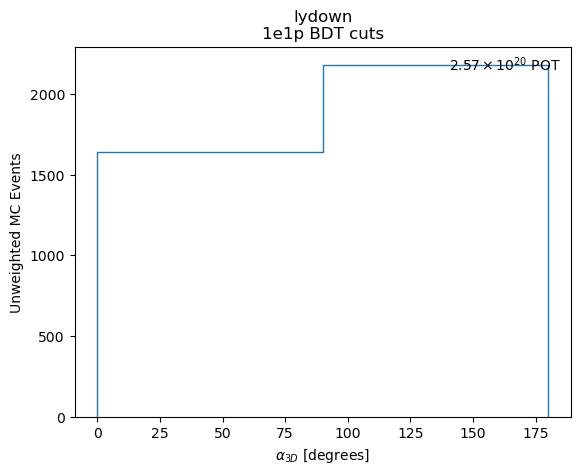

('RecoElecE', 16, (0, 4), 'Reconstructed Electron Energy [GeV]')



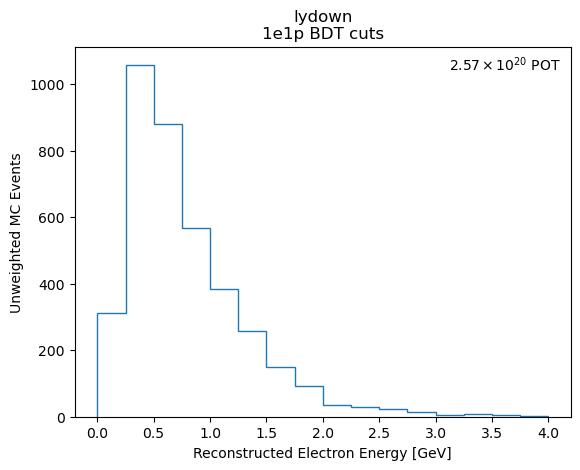

('RecoElecModMom', 20, (0, 5), 'Modulus of the Reconstructed Electron Momentum [GeV/c]')



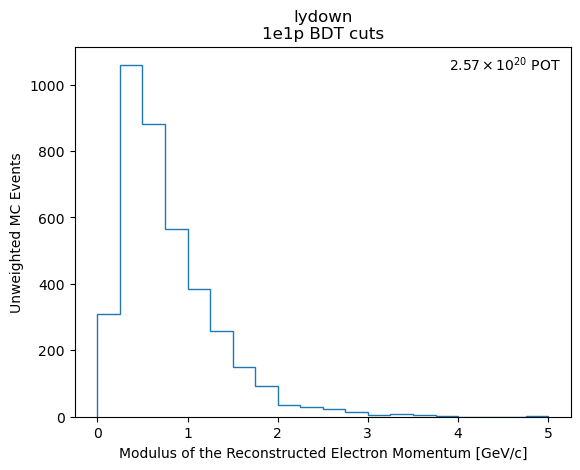

('RecoElecMomX', 12, (-1.5, 1.5), 'x component of Reconstructed Electron Momentum [GeV/c]')



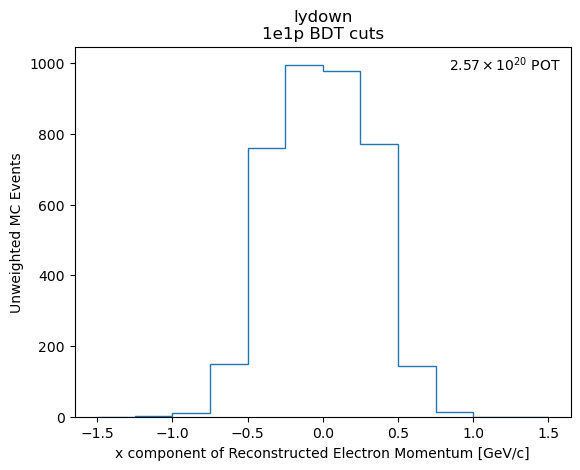

('RecoElecMomY', 12, (-1.5, 1.5), 'y component of Reconstructed Electron Momentum [GeV/c]')



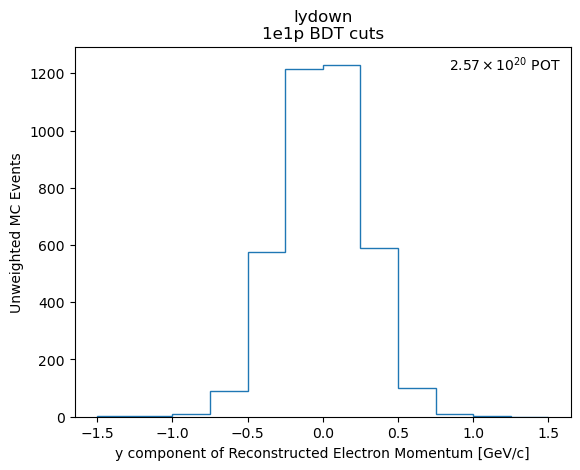

('RecoLeadProtonKE', 10, (0, 1), 'Reconstructed Proton Kinetic Energy [GeV]')



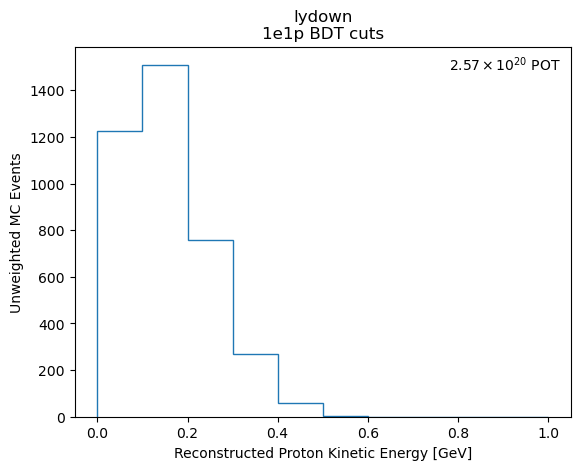

('RecoLeadProtonMomX', 20, (-1, 1), 'x component of Reconstructed Proton Momentum [GeV/c]')



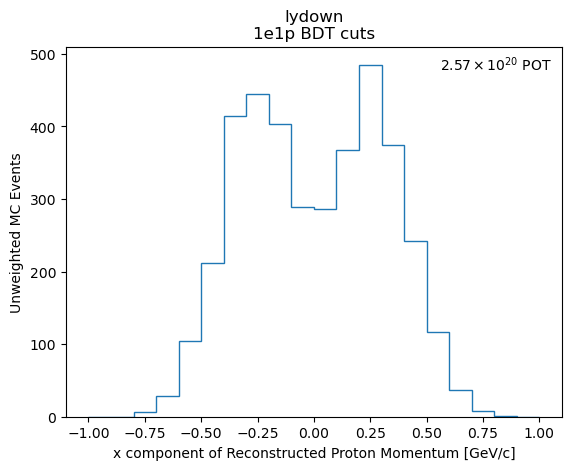

<Figure size 640x480 with 0 Axes>

In [5]:
#detector_variations = ["cv","lydown","lyatt","lyrayleigh","sce","recomb2","wiremodx","wiremodyz","wiremodthetaxz","wiremodthetayz"]
detector_variations = ["lydown"]

RUN = ["3"]
blinded = True
data="bnb"

run_combo = "Run"
for run in RUN:
    run_combo += run

selection = "OnePBDT"
preselection = "OneP_new"
from microfit import selections as sel
query = f"{sel.preselection_categories[preselection]['query']} and {sel.selection_categories[selection]['query']}"
query_title = f"{sel.selection_categories[selection]['title']}"

#for variation in dl.detector_variations:
for variation in detector_variations:
    sel_DVrundata = {}
    DVrundata, DVweights, DVdata_pot = dl.load_runs_detvar(
        RUN,
        dataset=data,
        variation=variation,
        blinded=True,
        loadsystematics=False,
        loadpi0variables=False,
        loadshowervariables=True,
        loadrecoveryvars=False,
        loadnumuvariables=False,
        use_lee_weights=False,
        use_bdt=True,
        pi0scaling=0,
        load_crt_vars=False,
        load_numu_tki=False,
        load_nue_tki=True,
        full_path="",
        )
    
    for k, df in DVrundata.items():
        sel_DVrundata[k] = df.query(query, engine='python')

    summed_sel_DVrundata = pd.concat([df for k, df in sel_DVrundata.items()])

    title = f"{variation}" + "\n" + query_title
    pot_in_sci_notation = "{:.2e}".format(DVdata_pot)
    base, exponent = pot_in_sci_notation.split("e")
    pot_label = f"${base} \\times 10^{{{int(exponent)}}}$ POT"

    for binning_def in vdef.TKI_variables_1e1p:
        # some binning definitions have more than 4 elements,
        # we ignore the last ones for now
        #binning = hist.Binning.from_config(*binning_def[:4])
        binning = hist.Binning.from_config(*binning_def)  # for variable bin sizes
        print(binning_def)
        print()
        label = binning_def[0].lstrip("Reco")

        # plt.hist(sel_DVrundata["nue"][binning.variable], binning.bin_edges, histtype='step', label='Intrinsic nue')
        # plt.hist(sel_DVrundata["mc"][binning.variable], binning.bin_edges, histtype='step', label='MC - nu overlay')
        plt.hist(summed_sel_DVrundata[binning.variable], binning.bin_edges, histtype='step', label='Summed')
        #plt.legend()
        #plt.yscale('log')
        plt.xlabel(f'{binning.variable_tex}')
        plt.ylabel(f'Unweighted MC Events')
        plt.title(title)
        plt.text(0.98, 0.98, pot_label, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right')
        plt.savefig(f'analysis_1e1p/analysis_plots/detsys/investigate/stats_detvar_{variation}_{preselection}_{selection}_{data}_{run_combo}_{binning_def[0]}.pdf', bbox_inches='tight')
        plt.savefig(f'analysis_1e1p/analysis_plots/detsys/investigate/stats_detvar_{variation}_{preselection}_{selection}_{data}_{run_combo}_{binning_def[0]}.png', bbox_inches='tight')
        plt.show()
        plt.clf()
    


In [13]:
print(DVrundata.keys())

dict_keys(['mc', 'nue'])


In [14]:
print(DVrundata)

{'mc':        n_showers_contained  trkshrhitdist2  npion  hits_ratio  knobRPAup  \
entry                                                                      
0                        1        3.345504      1    0.072425   1.000000   
1                        2       -1.000000      0    1.000000   1.000000   
2                        1        0.322983      0    0.308257   1.000000   
3                        1        5.063776      0    0.585831   1.000000   
4                        1        1.064599      0    0.660465   1.162946   
...                    ...             ...    ...         ...        ...   
12349                    3       79.800041      0    0.333011   1.000000   
12350                    1        5.005919      0    0.097802   1.055687   
12351                    1       10.072603      0    0.279055   1.000000   
12352                    3        0.301125      0    0.549521   1.000000   
12353                    2       40.629196      2    0.612150   1.000000   

    